In [1]:
import networkx as nx
import matplotlib.pyplot as plt 
import itertools
import time
import pandas as pd

In [2]:
G1 = nx.read_edgelist("n=10,m=10.txt")
G2 = nx.read_edgelist("n=10,m=20.txt")
G3 = nx.read_edgelist("n=10,m=30.txt")
G4 = nx.read_edgelist("n=10,m=40.txt")

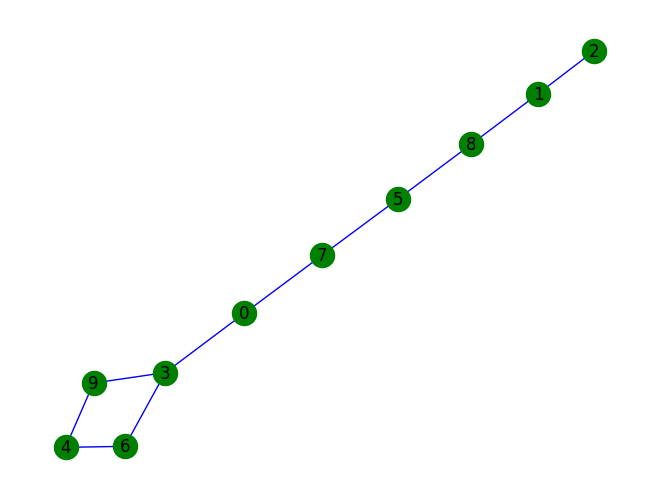

In [3]:
nx.draw(G1, with_labels=True, node_color='green', edge_color='blue')

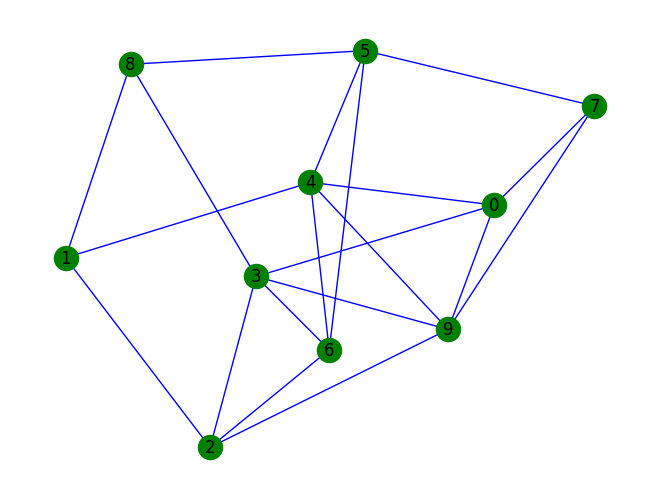

In [4]:
nx.draw(G2, with_labels=True, node_color='green', edge_color='blue')

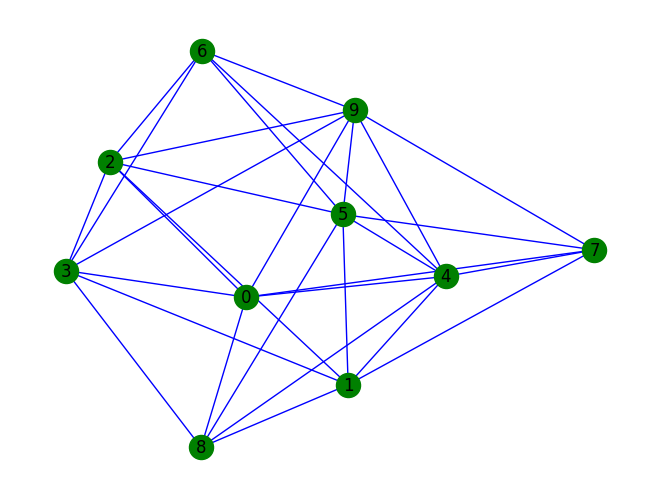

In [5]:
nx.draw(G3, with_labels=True, node_color='green', edge_color='blue')

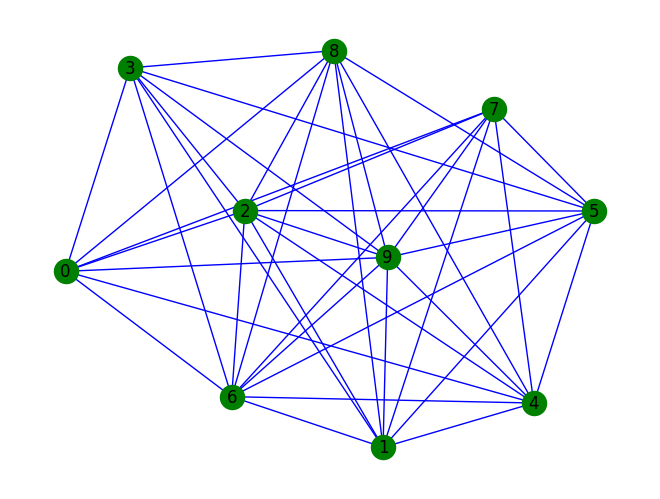

In [6]:
nx.draw(G4, with_labels=True, node_color='green', edge_color='blue')

In [7]:
# the function to find all possible subgraphs (here subsets) i.e. itertools.combinations(nodes, r) has been generated from chatgpt
def vertex_cover_brute_force(G,n):
    nodes = list(G.nodes())
    for r in range(n + 1):
        for subset in itertools.combinations(nodes, r):
            is_cover = True
            for u, v in G.edges():
                if not (u in subset or v in subset):
                    is_cover = False
                    break
            if is_cover:
                return set(subset)
    return set()

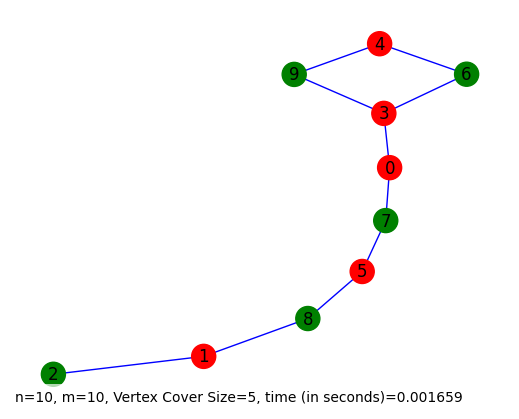

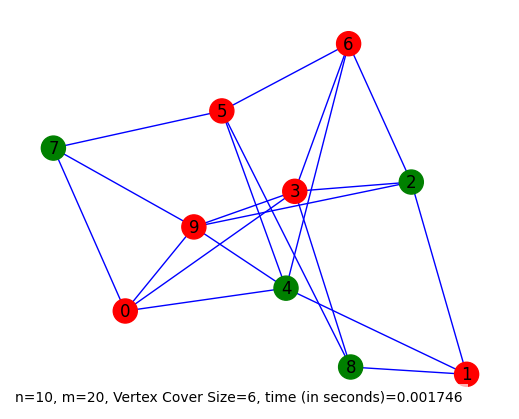

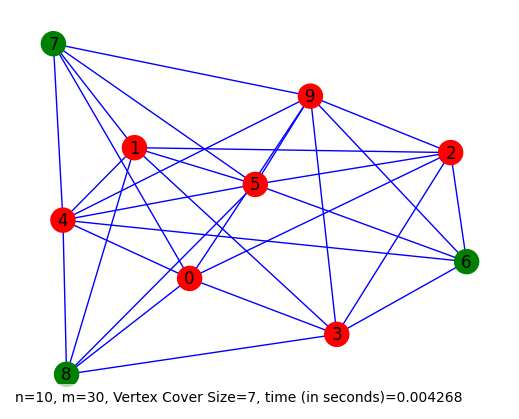

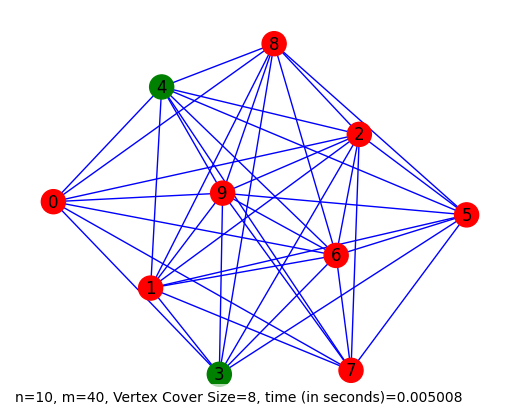

In [8]:
# used plt.text from chatgpt to ensure saving values of n,m and size of vertex cover an the time taken
results = []
n=10
m = [10, 20, 30, 40]
graphs = [G1, G2, G3, G4]

for i, graph in enumerate(graphs, start=1): 
    start_time = time.perf_counter()
    vc = vertex_cover_brute_force(graph,n)
    end_time = time.perf_counter()
    
    node_colors = ['red' if node in vc else 'green' for node in graph.nodes()]
    
    plt.figure(figsize=(5, 4))
   
    nx.draw(graph, with_labels=True, node_color=node_colors, edge_color="blue")
    nx.write_adjlist(graph, f"graph{i}out.txt")
    
    plt.text(0.01, 0.02,
             f"n=10, m={m[i-1]}, Vertex Cover Size={len(vc)}, time (in seconds)={(end_time - start_time):.6f}",
             transform=plt.gca().transAxes, fontsize=10, color="black", bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))

    plt.savefig(f"n=10,m={m[i-1]}.png")
    
    results.append({
        "n": 10,
        "m": m[i-1],
        "vertex cover size": len(vc),
        "time (in seconds)": end_time - start_time
    })

In [9]:
# Create a DataFrame
df = pd.DataFrame(results)

file_path = 'vertex_cover_results.csv'
df.to_csv(file_path, index=False)

In [10]:
df_res = pd.read_csv('vertex_cover_results.csv')
df_res

,n,m,vertex cover size,time (in seconds)
0,10,10,5,0.001659
1,10,20,6,0.001746
2,10,30,7,0.004268
3,10,40,8,0.005008
